# Task 1

## assignment-data.csv

In [1]:
import torch
import matplotlib.pyplot as plt
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Check PyTorch version
torch.__version__

'2.12.0+cpu'

In [2]:
import pandas as pd
df=pd.read_csv("assignment-data.csv")
df.head(6)  #check if dataset is loaded

,x,y
0,0.0,2.00
1,0.2,2.12
2,0.4,2.48
3,0.6,3.08
4,0.8,3.92
5,1.0,5.00


In [3]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


In [4]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [5]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

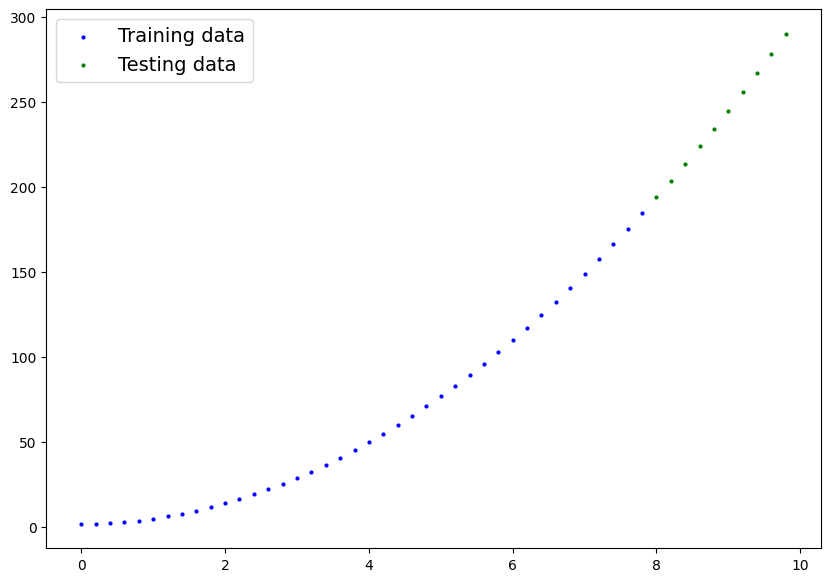

In [6]:
plot_predictions(X_train, y_train, X_test, y_test)

In [7]:
# Define model
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

In [9]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionNN()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([[0.7645]], requires_grad=True),
 Parameter containing:
 tensor([0.8300], requires_grad=True)]

In [10]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[6.9463],
        [7.0992],
        [7.2521],
        [7.4050],
        [7.5579]])

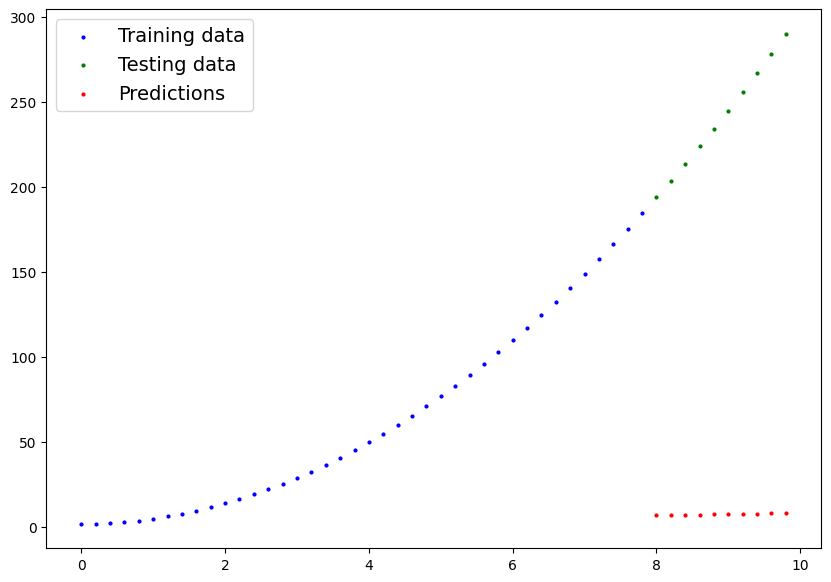

In [12]:
plot_predictions(predictions=y_preds)

In [11]:
# Loss Function and Optimizer

loss_fn = nn.L1Loss()      # MAE

optimizer = torch.optim.SGD(
    params=model_0.parameters(),
    lr=0.01
)

In [16]:
# Training

torch.manual_seed(42)

epochs = 600

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):

    model_0.train()

    y_pred = model_0(X_train)

    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_0.eval()

    with torch.inference_mode():

        test_pred = model_0(X_test)

        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:

        epoch_count.append(epoch)
        train_loss_values.append(loss.item())
        test_loss_values.append(test_loss.item())

        print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")

Epoch: 0 | Train Loss: 32.9293 | Test Loss: 167.5564
Epoch: 10 | Train Loss: 32.0263 | Test Loss: 164.8653
Epoch: 20 | Train Loss: 31.1832 | Test Loss: 162.2779
Epoch: 30 | Train Loss: 30.3648 | Test Loss: 159.7165
Epoch: 40 | Train Loss: 29.5999 | Test Loss: 157.2519
Epoch: 50 | Train Loss: 28.8669 | Test Loss: 154.8289
Epoch: 60 | Train Loss: 28.1709 | Test Loss: 152.4795
Epoch: 70 | Train Loss: 27.5235 | Test Loss: 150.2039
Epoch: 80 | Train Loss: 26.8856 | Test Loss: 147.9596
Epoch: 90 | Train Loss: 26.3229 | Test Loss: 145.8403
Epoch: 100 | Train Loss: 25.7602 | Test Loss: 143.7210
Epoch: 110 | Train Loss: 25.2431 | Test Loss: 141.7009
Epoch: 120 | Train Loss: 24.7632 | Test Loss: 139.7467
Epoch: 130 | Train Loss: 24.2834 | Test Loss: 137.7926
Epoch: 140 | Train Loss: 23.8697 | Test Loss: 135.9952
Epoch: 150 | Train Loss: 23.4697 | Test Loss: 134.2151
Epoch: 160 | Train Loss: 23.0697 | Test Loss: 132.4351
Epoch: 170 | Train Loss: 22.7317 | Test Loss: 130.8198
Epoch: 180 | Train Lo

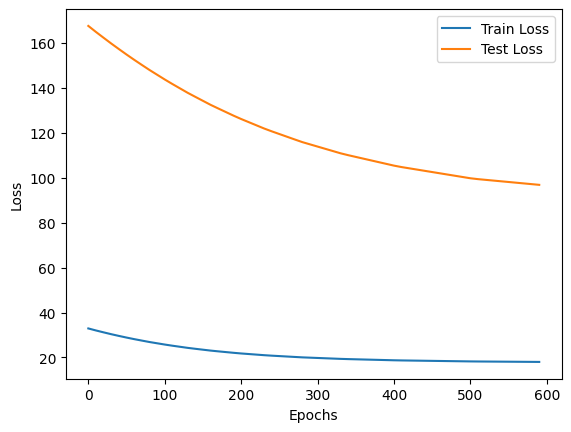

In [17]:
# Loss Curve

plt.plot(epoch_count, train_loss_values, label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

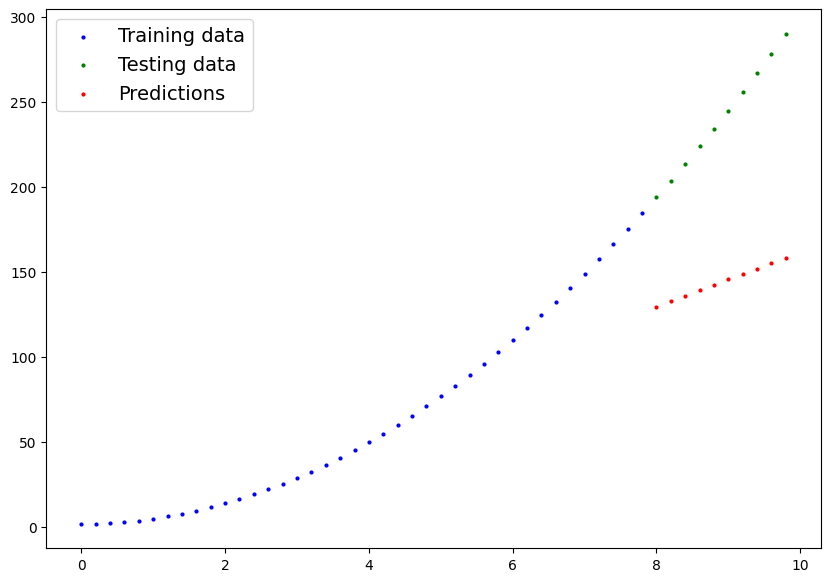

In [19]:
# Evaluation

model_0.eval()

with torch.inference_mode():
    y_preds = model_0(X_test)

plot_predictions(
    predictions=y_preds
)

## assignment-data2.csv

In [20]:
import pandas as pd
import torch

df = pd.read_csv("assignment-data2.csv")
df.head(6)

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00
5,-8.8,543.08


In [21]:
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([99, 1])
torch.Size([99, 1])


In [22]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(79, 79, 20, 20)

In [23]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

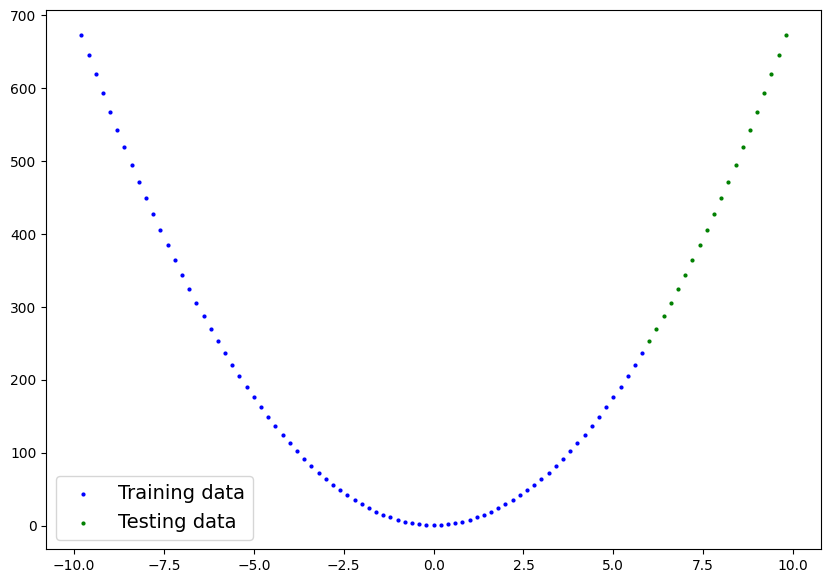

In [24]:
plot_predictions(X_train, y_train, X_test, y_test)

In [27]:
# Define model
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

In [29]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionNN()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([[0.7645]], requires_grad=True),
 Parameter containing:
 tensor([0.8300], requires_grad=True)]

In [30]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)


In [31]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 20
Number of predictions made: 20
Predicted values:
tensor([[5.4172],
        [5.5701],
        [5.7231],
        [5.8760],
        [6.0289],
        [6.1818],
        [6.3347],
        [6.4876],
        [6.6405],
        [6.7934],
        [6.9463],
        [7.0992],
        [7.2521],
        [7.4050],
        [7.5579],
        [7.7109],
        [7.8638],
        [8.0167],
        [8.1696],
        [8.3225]])


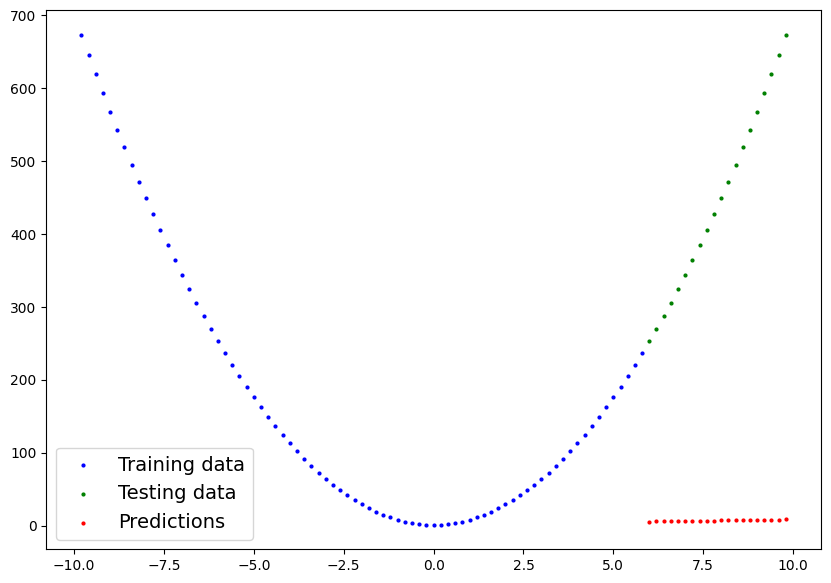

In [32]:
plot_predictions(predictions=y_preds)

In [33]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

In [34]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 600

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 175.299072265625 | MAE Test Loss: 440.4580993652344 
Epoch: 10 | MAE Train Loss: 174.799072265625 | MAE Test Loss: 441.9381408691406 
Epoch: 20 | MAE Train Loss: 174.30055236816406 | MAE Test Loss: 443.419189453125 
Epoch: 30 | MAE Train Loss: 173.80557250976562 | MAE Test Loss: 444.90167236328125 
Epoch: 40 | MAE Train Loss: 173.31057739257812 | MAE Test Loss: 446.3841857910156 
Epoch: 50 | MAE Train Loss: 172.8198699951172 | MAE Test Loss: 447.86572265625 
Epoch: 60 | MAE Train Loss: 172.3340301513672 | MAE Test Loss: 449.3526306152344 
Epoch: 70 | MAE Train Loss: 171.84864807128906 | MAE Test Loss: 450.84027099609375 
Epoch: 80 | MAE Train Loss: 171.36325073242188 | MAE Test Loss: 452.32781982421875 
Epoch: 90 | MAE Train Loss: 170.8778839111328 | MAE Test Loss: 453.8154296875 
Epoch: 100 | MAE Train Loss: 170.4003143310547 | MAE Test Loss: 455.29754638671875 
Epoch: 110 | MAE Train Loss: 169.923583984375 | MAE Test Loss: 456.77972412109375 
Epoch: 120 | M

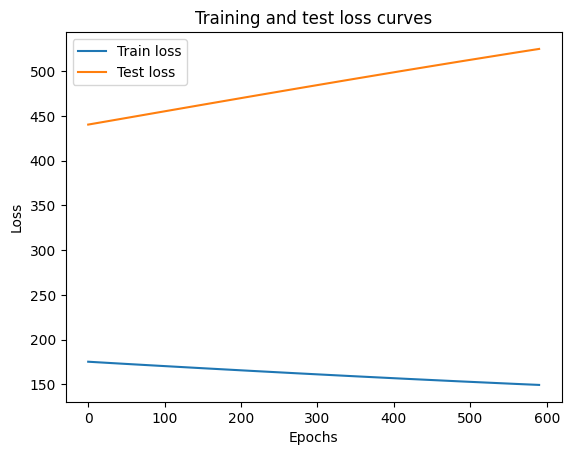

In [35]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

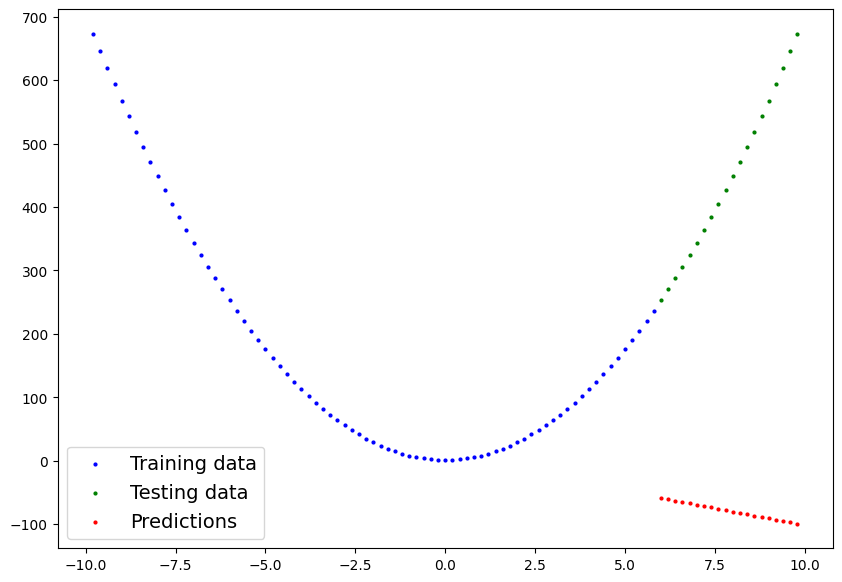

In [36]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

## linear-regression-data1.csv

In [37]:
import pandas as pd
import torch

df = pd.read_csv("linear-regression-data1.csv")
df.head(6)

,x,y
0,0.00,0.300
1,0.02,0.314
2,0.04,0.328
3,0.06,0.342
4,0.08,0.356
5,0.10,0.370


In [38]:
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


In [39]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [40]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

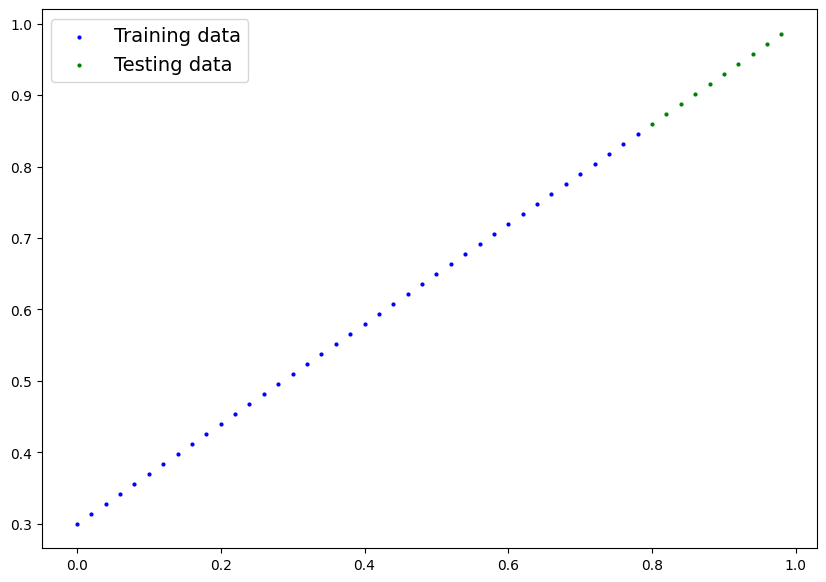

In [41]:
plot_predictions(X_train, y_train, X_test, y_test)

In [42]:
# Define model
class LinearRegressionNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

In [44]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionNN()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([[0.7645]], requires_grad=True),
 Parameter containing:
 tensor([0.8300], requires_grad=True)]

In [45]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)


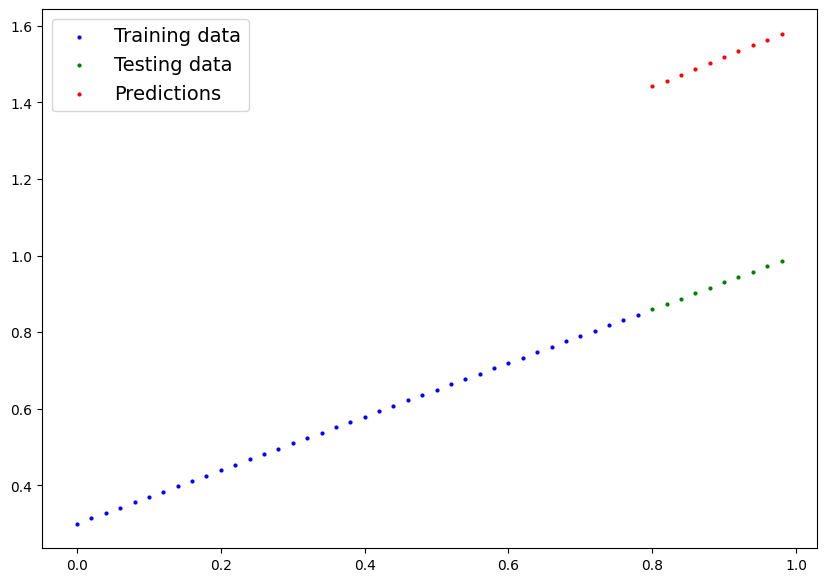

In [46]:
plot_predictions(predictions=y_preds)

In [47]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

In [48]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 600

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.5551779866218567 | MAE Test Loss: 0.5739762187004089 
Epoch: 10 | MAE Train Loss: 0.4399680495262146 | MAE Test Loss: 0.4392663538455963 
Epoch: 20 | MAE Train Loss: 0.3247582018375397 | MAE Test Loss: 0.30455657839775085 
Epoch: 30 | MAE Train Loss: 0.20954827964305878 | MAE Test Loss: 0.16984674334526062 
Epoch: 40 | MAE Train Loss: 0.09433844685554504 | MAE Test Loss: 0.03513689711689949 
Epoch: 50 | MAE Train Loss: 0.023886386305093765 | MAE Test Loss: 0.04784906655550003 
Epoch: 60 | MAE Train Loss: 0.0199567973613739 | MAE Test Loss: 0.04580312222242355 
Epoch: 70 | MAE Train Loss: 0.016517987474799156 | MAE Test Loss: 0.0375305712223053 
Epoch: 80 | MAE Train Loss: 0.013089170679450035 | MAE Test Loss: 0.029944902285933495 
Epoch: 90 | MAE Train Loss: 0.009653178043663502 | MAE Test Loss: 0.02167237363755703 
Epoch: 100 | MAE Train Loss: 0.006215679459273815 | MAE Test Loss: 0.014086711220443249 
Epoch: 110 | MAE Train Loss: 0.002787243574857712 | MA

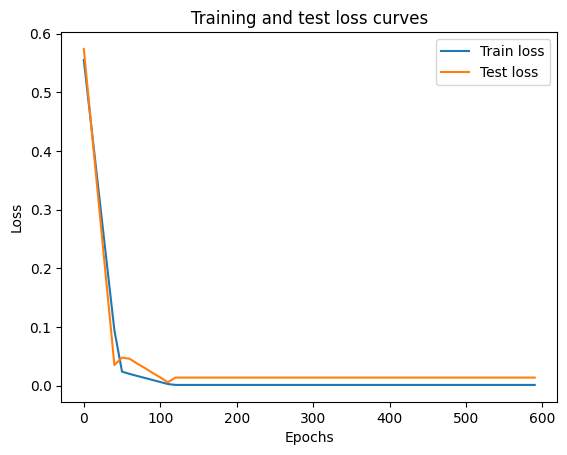

In [49]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

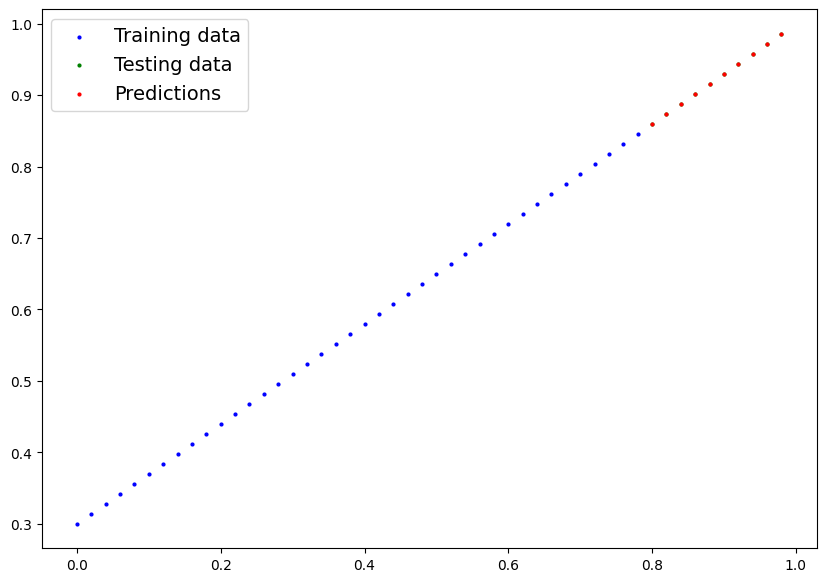

In [50]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

### linear-regression-data1.csv:

The model is capable of learning from this dataset because it represents a linear relationship.


### assignment-data.csv:
The model can be trained on the dataset; however, it may not be appropriate if the data contains non-linear patterns. 


### assignment-data2.csv:
Although the model can be trained, it is not suitable for learning complex non-linear relationships. 

# Task 2

## Data retrieval  and collection

In [51]:
import pandas as pd

path = "binary_classification_moons.csv"

data = pd.read_csv(path)
data.head(6)

,X1,X2,label
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0
5,0.579542,-0.352979,1


## Data cleaning

In [52]:
data.describe()

,X1,X2,label
count,1000.000000,1000.000000,1000.00000
mean,0.499552,0.249196,0.50000
std,0.867371,0.494822,0.50025
min,-1.061751,-0.571697,0.00000
25%,-0.019860,-0.216408,0.00000
50%,0.502008,0.248686,0.50000
75%,1.020851,0.694288,1.00000
max,2.064637,1.042677,1.00000


## Algorithm selection

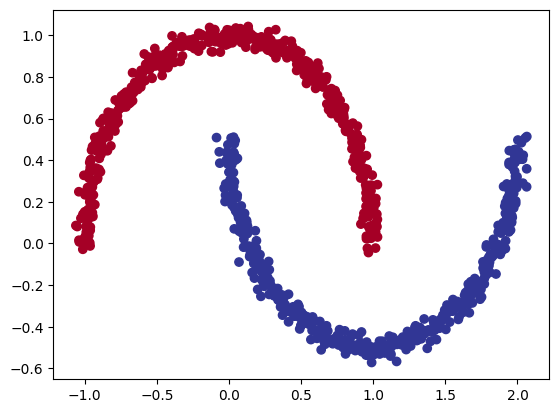

In [53]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(
            x=data.X1, 
            y=data.X2, 
            c=data.label, 
            cmap=plt.cm.RdYlBu
            );

In [54]:
# vectorizing X1 and X2 into a single tensor/nparray

X = data[['X1', 'X2']].values
y = data['label'].values

In [55]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[-0.00933187  0.39098105]
 [ 0.95457387 -0.47375583]
 [ 0.9185256  -0.42519648]
 [ 0.41276802 -0.37638459]
 [-0.84532016  0.52879908]]

First 5 y labels:
[1 1 1 1 0]


In [56]:
# Check the shapes of our features and labels
X.shape, y.shape


((1000, 2), (1000,))

In [57]:
# Turn data into tensors
# Otherwise this causes issues with computations later on
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# View the first five samples
X[:5], y[:5]

C:\Users\rosha\AppData\Local\Temp\ipykernel_21164\3536051194.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y = torch.from_numpy(y).type(torch.float)


(tensor([[-0.0093,  0.3910],
         [ 0.9546, -0.4738],
         [ 0.9185, -0.4252],
         [ 0.4128, -0.3764],
         [-0.8453,  0.5288]]),
 tensor([1., 1., 1., 1., 0.]))

In [58]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [59]:
# Standard PyTorch imports
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [60]:
# 1. Construct a model class that subclasses nn.Module
class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling X and y input and output shapes
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features (X), produces 5 features
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features, produces 1 feature (y)
    
    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        # Return the output of layer_2, a single feature, the same shape as y
        return self.layer_2(self.layer_1(x)) # computation goes through layer_1 first then the output of layer_1 goes through layer_2

# 4. Create an instance of the model and send it to target device
model_0 = ModelV0().to(device)
model_0

ModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [61]:
model = model_0

In [62]:
# Make predictions with the model
untrained_preds = model(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[-0.1435],
        [-0.0799],
        [-0.1176],
        [-0.0775],
        [-0.0713],
        [-0.0593],
        [-0.0908],
        [-0.0988],
        [-0.1263],
        [-0.0826]], grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


## Loss function selection

In [63]:
# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

In [64]:
# View the frist 5 outputs of the forward pass on the test data
y_logits = model(X_test.to(device))[:5]
y_logits

tensor([[-0.1435],
        [-0.0799],
        [-0.1176],
        [-0.0775],
        [-0.0713]], grad_fn=<SliceBackward0>)

In [66]:
# Use sigmoid on model logits
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4642],
        [0.4800],
        [0.4706],
        [0.4806],
        [0.4822]], grad_fn=<SigmoidBackward0>)

In [67]:
# Find the predicted labels (round the prediction probabilities)
y_preds = torch.round(y_pred_probs)

# In full
y_pred_labels = torch.round(torch.sigmoid(model(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()


tensor([True, True, True, True, True])


tensor([0., 0., 0., 0., 0.], grad_fn=<SqueezeBackward0>)

In [68]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

## Model Learning

In [69]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

## Model Evaluation

In [70]:
from utils import train_and_test_loop

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)


Epoch: 0 | Loss: 0.69395, Accuracy: 50.00% | Test loss: 0.68147, Test acc: 58.50%
Epoch: 10 | Loss: 0.57149, Accuracy: 79.12% | Test loss: 0.57350, Test acc: 75.00%
Epoch: 20 | Loss: 0.48652, Accuracy: 81.12% | Test loss: 0.49746, Test acc: 79.00%
Epoch: 30 | Loss: 0.42603, Accuracy: 82.00% | Test loss: 0.44278, Test acc: 80.50%
Epoch: 40 | Loss: 0.38463, Accuracy: 82.25% | Test loss: 0.40451, Test acc: 81.00%
Epoch: 50 | Loss: 0.35657, Accuracy: 82.88% | Test loss: 0.37765, Test acc: 81.50%
Epoch: 60 | Loss: 0.33707, Accuracy: 83.12% | Test loss: 0.35814, Test acc: 81.50%
Epoch: 70 | Loss: 0.32288, Accuracy: 83.75% | Test loss: 0.34328, Test acc: 81.50%
Epoch: 80 | Loss: 0.31201, Accuracy: 84.00% | Test loss: 0.33141, Test acc: 82.00%
Epoch: 90 | Loss: 0.30329, Accuracy: 84.75% | Test loss: 0.32152, Test acc: 83.00%


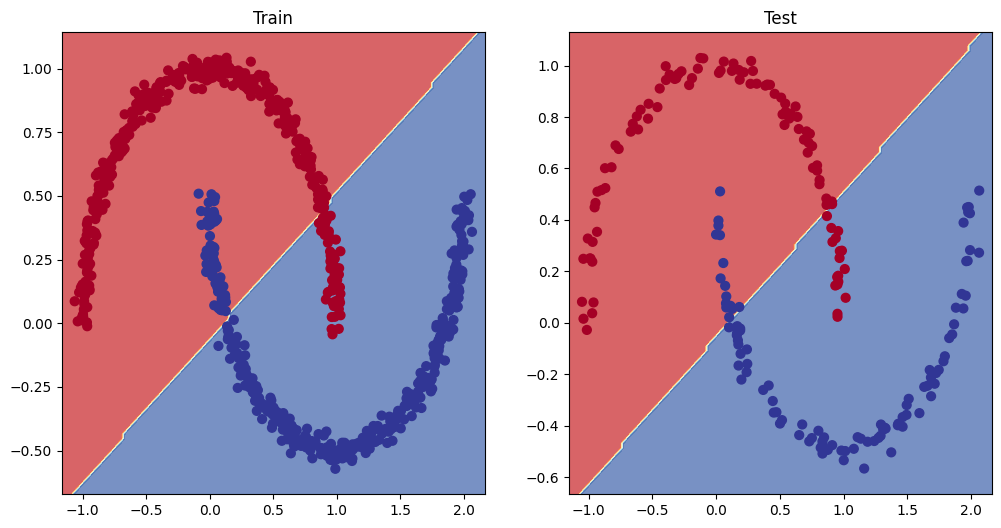

In [71]:
from utils import plot_decision_boundary

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

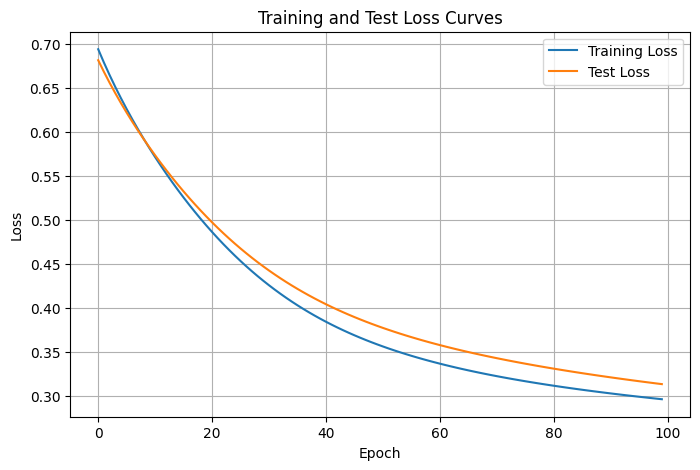

In [72]:
import matplotlib.pyplot as plt

def plot_loss_curves(train_losses, test_losses):
    """
    Plots training and testing loss curves.

    Args:
        train_losses (list): Loss values from training
        test_losses (list): Loss values from testing
    """
    epochs = range(len(train_losses))

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, test_losses, label="Test Loss")
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss_curves(train_losses, test_losses)

## Improving the model

In [96]:
class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=7)
        self.layer_4 = nn.Linear(in_features=7, out_features=5)
        self.layer_5 = nn.Linear(in_features=5 ,out_features=1)
        
    def forward(self, x): # note: always make sure forward is spelt correctly!
        # Creating a model like this is the same as below, though below
        # generally benefits from speedups where possible.
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z
        return self.layer_5(self.layer_4(self.layer_3(self.layer_2(self.layer_1(x)))))

model_1 = ModelV1().to(device)
model_1

ModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=7, bias=True)
  (layer_4): Linear(in_features=7, out_features=5, bias=True)
  (layer_5): Linear(in_features=5, out_features=1, bias=True)
)

In [97]:
model = model_1
epochs = 1000

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

Epoch: 0 | Loss: 0.68203, Accuracy: 50.00% | Test loss: 0.67851, Test acc: 50.00%
Epoch: 10 | Loss: 0.64177, Accuracy: 85.50% | Test loss: 0.64016, Test acc: 81.00%
Epoch: 20 | Loss: 0.57547, Accuracy: 82.50% | Test loss: 0.57599, Test acc: 81.50%
Epoch: 30 | Loss: 0.46245, Accuracy: 82.12% | Test loss: 0.47018, Test acc: 81.50%
Epoch: 40 | Loss: 0.35102, Accuracy: 83.38% | Test loss: 0.36845, Test acc: 84.00%
Epoch: 50 | Loss: 0.29934, Accuracy: 83.75% | Test loss: 0.31662, Test acc: 83.50%
Epoch: 60 | Loss: 0.27696, Accuracy: 85.25% | Test loss: 0.28971, Test acc: 85.50%
Epoch: 70 | Loss: 0.26293, Accuracy: 86.00% | Test loss: 0.27152, Test acc: 87.50%
Epoch: 80 | Loss: 0.25315, Accuracy: 87.12% | Test loss: 0.25855, Test acc: 88.00%
Epoch: 90 | Loss: 0.24679, Accuracy: 87.62% | Test loss: 0.24988, Test acc: 88.50%
Epoch: 100 | Loss: 0.24309, Accuracy: 88.12% | Test loss: 0.24453, Test acc: 89.00%
Epoch: 110 | Loss: 0.24115, Accuracy: 88.50% | Test loss: 0.24142, Test acc: 89.50%
Epo

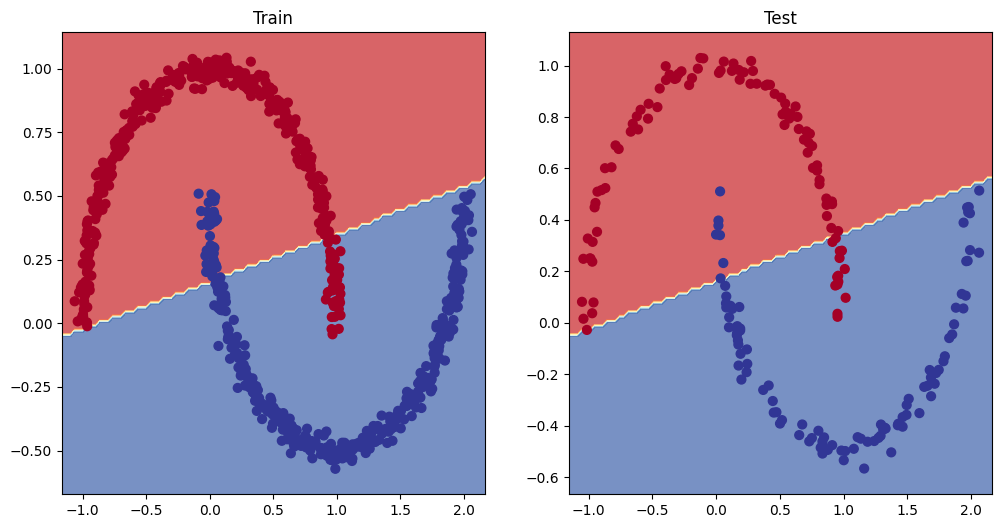

In [98]:
train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

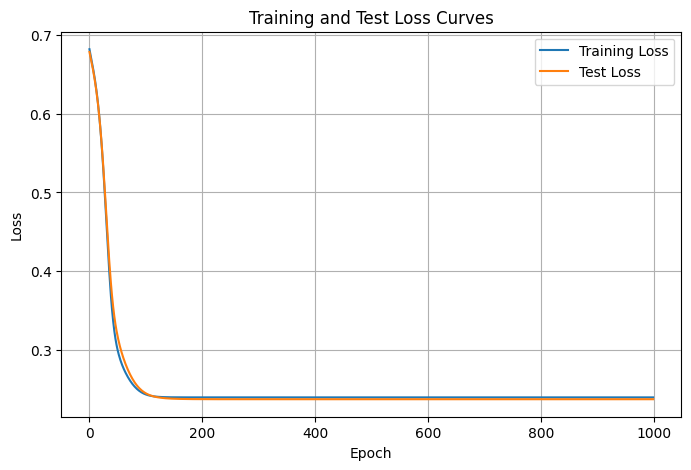

In [99]:
plot_loss_curves(train_losses, test_losses)

The LinearRegressionNN model is not suitable for the binary_classification_moons.csv dataset because it can only learn linear relationships, whereas the moon dataset has a non-linear structure.


The ModelV0 model is also not suitable for the moon dataset. Although it contains two linear layers, the absence of activation functions means it still behaves like a linear model and cannot learn complex non-linear decision boundaries.

# Task 3

In [109]:
class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # <- add in ReLU activation function
        # Can also put sigmoid in the model 
        # This would mean you don't need to use it on the predictions
        # self.sigmoid = nn.Sigmoid()

    def forward(self, x):
      # Intersperse the ReLU activation function between layers
       return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
    
model_2 = ModelV2().to(device)
model_2

ModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [110]:
model = model_2
epochs = 2000

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(), 
                            lr=0.1)

Epoch: 0 | Loss: 0.70523, Accuracy: 30.00% | Test loss: 0.70330, Test acc: 33.50%
Epoch: 10 | Loss: 0.69760, Accuracy: 29.88% | Test loss: 0.69638, Test acc: 33.50%
Epoch: 20 | Loss: 0.69073, Accuracy: 63.00% | Test loss: 0.69006, Test acc: 69.50%
Epoch: 30 | Loss: 0.68367, Accuracy: 74.38% | Test loss: 0.68348, Test acc: 75.50%
Epoch: 40 | Loss: 0.67561, Accuracy: 81.38% | Test loss: 0.67585, Test acc: 81.00%
Epoch: 50 | Loss: 0.66569, Accuracy: 79.12% | Test loss: 0.66646, Test acc: 78.00%
Epoch: 60 | Loss: 0.65291, Accuracy: 78.62% | Test loss: 0.65440, Test acc: 72.00%
Epoch: 70 | Loss: 0.63598, Accuracy: 77.25% | Test loss: 0.63841, Test acc: 72.00%
Epoch: 80 | Loss: 0.61316, Accuracy: 77.62% | Test loss: 0.61687, Test acc: 72.50%
Epoch: 90 | Loss: 0.58335, Accuracy: 77.38% | Test loss: 0.58894, Test acc: 72.50%
Epoch: 100 | Loss: 0.54838, Accuracy: 77.75% | Test loss: 0.55648, Test acc: 72.50%
Epoch: 110 | Loss: 0.51009, Accuracy: 78.50% | Test loss: 0.52111, Test acc: 73.50%
Epo

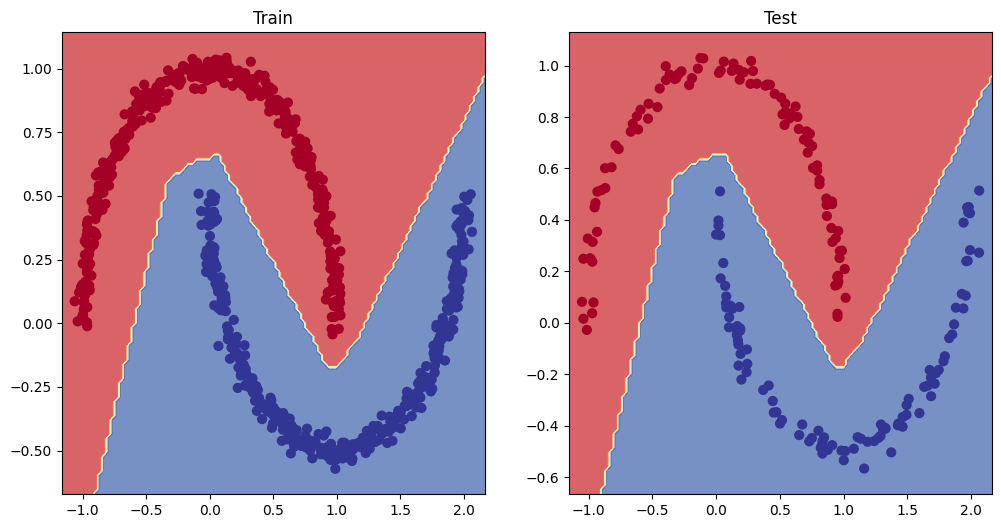

In [111]:
train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

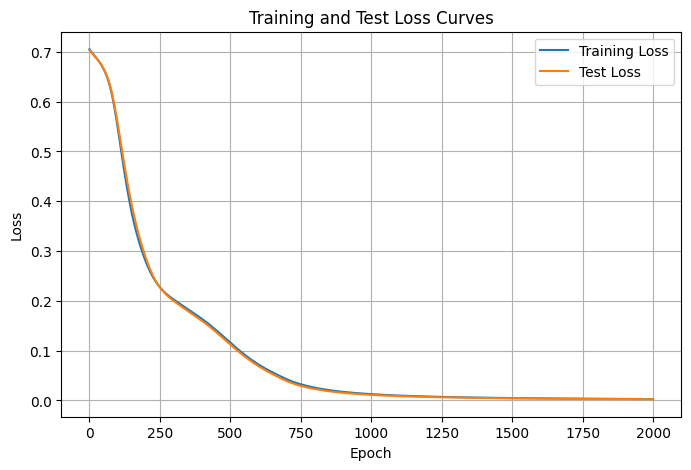

In [112]:
plot_loss_curves(train_losses, test_losses)

The modified model with additional hidden layers and ReLU activation functions is suitable for the moon dataset. The non-linear activations enable the network to learn the curved patterns in the data, resulting in improved classification performance.